# Project: Investigate a Dataset - FBI Gun Data

## Table of Contents
<ul>
<li><a href="#intro">Introduction</a></li>
<li><a href="#wrangling">Data Wrangling</a></li>
<li><a href="#eda">Exploratory Data Analysis</a></li>
<li><a href="#conclusions">Conclusions</a></li>
</ul>

<a id='intro'></a>
## Introduction

### Dataset Description 

This dataset comes from the FBI's National Instant Criminal Background Check System(NICS). The NICS is used by to determine whether a prospective buyer is eligible to buy firearms or explosives. Gun shops call into this system to ensure that each customer does not have a criminal record or isn’t otherwise ineligible to make a purchase. This data has also been suplemented with state level datea from census.gov. Information included in the NICS data includes the number of firearm checks by month, state and type. The census data contains serveral state level varialbes.
Note this data is only related to background checks and does not mean that there was in fact a purchase of a firearm.

There are serveral columns in the data, some have obvious meanings, others require some explanation.
This data is also grouped into segments 

Checks initiated by officially-licensed Federal Firesarms Licenesee(FFL) or law enforcement agency(prior to issuance of firearm relate permit/transfer):  
- month - when the check took place
- state - where the check was initiated from
- permit - number of permits issued
- permit_recheck - number of permits rechecked
- handgun - number of handguns permits issued
- long_gun - number of rifles or shotguns permits issued
- other - permits for non-handguns or long_guns, for instance, a shotgun with a pistol grip instead of a stock.
- multiple - number of checks involving mulitple types of firearms
- admin - administrative checks for other authorized uses of the NICS

Pre-Pawn - these are prospective firearm transferees seeking to pledges or pawns a firearm, *before* pledging/pawning the firearm:
- prepawn_handgun
- prepawn_long_gun
- prepawn_other

Redemption - these are prospective firearm transferees seekignto regain possession of a firearm *after* pledging/pawning the firearm:
- redemption_handgun
- redemption_long_gun
- redemption_other

Returned - checks requested by law enforcement agencies prior to returning a firemarm in their possession to the respective transferee to ensure the individual is not prohibited from possessing a firearm: 
- returned_handgun
- returned_long_gun
- returned_other

Rentals - checks on prospective firearm transferees attempting possess a firearm that is loaned or rented for use off the premesis of the business:
- rentals_handgun
- rentals_long_gun

Private Sale - these are checks requested by an officially-licensed FFL on firearm transferees attempting to possess a firearm from a private party seller who is not an officially licensed FFL: 
- private_sale_handgun
- private_sale_long_gun
- private_sale_other

Returned to Seller(Private Sale) - these are checks requested by an officially-licensed FFL on firearm transferees attempting to possess a firearm from a private party seller who is not an officially licensed FFL:
- return_to_seller_handgun
- return_to_seller_long_gun
- return_to_seller_other

totals - the total number of permits issued.


### Question(s) for Analysis
1. What states have the highest issuance of permits? what kind of permits? and what, if any correlation is there with the number of veterans?
2. How have firearm background checks changed over time across U.S. states, and how do these trends relate to population size, veteran density, and permit activity? Which states show sustained increases, decreases, or stable patterns when these factors are considered together?
3. How do firearm background check trends relate to demographic and socioeconomic characteristics across states (e.g., income, education, poverty, urbanization)?

In [1]:
# Use this cell to set up import statements for all of the packages that you
#   plan to use.

# While optional for current notebooks, if you are having trouble with visualizations,
#   remember to include a 'magic word' so that your visualizations are plotted
#   inline with the notebook. See this page for more:
#   http://ipython.readthedocs.io/en/stable/interactive/magics.html

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

<a id='wrangling'></a>
## Data Wrangling

I first explored the csv data to understand it's structure, time span and quality before creating dataframes.

### General Properties

The following cells explore the data in different ways to determine what needs to be cleaned.

In [2]:
# Load your data and print out a few lines. What is the size of your dataframe? 
#   Perform operations to inspect data types and look for instances of missing
#   or possibly errant data. There are at least 4 - 6 methods you can call on your
#   dataframe to obtain this information.

df_gun_data = pd.read_csv('Database_Ncis_and_Census_data/gun_data.csv', encoding='ISO-8859-1', delimiter=',')

# excluding the last 20 rows of the census data because it is explantory footer information and not data
# this will help with cleaning later
df_census_data = pd.read_csv('Database_Ncis_and_Census_data/US_Census_Data.csv', skipfooter=20, engine='python', encoding='ISO-8859-1', delimiter=',')

In [3]:
# output the shape and the head of the df_gun_data dataframe
# most of the columns data are floats and should be corrected to ints

print(f"Dataframe df_gun_data.shape: {df_gun_data.shape}\n")

print("df_gun_data first five rows:")
df_gun_data.head()

Dataframe df_gun_data.shape: (12485, 27)

df_gun_data first five rows:


,month,state,permit,permit_recheck,handgun,long_gun,other,multiple,admin,prepawn_handgun,...,returned_other,rentals_handgun,rentals_long_gun,private_sale_handgun,private_sale_long_gun,private_sale_other,return_to_seller_handgun,return_to_seller_long_gun,return_to_seller_other,totals
0,2017-09,Alabama,16717.0,0.0,5734.0,6320.0,221.0,317,0.0,15.0,...,0.0,0.0,0.0,9.0,16.0,3.0,0.0,0.0,3.0,32019
1,2017-09,Alaska,209.0,2.0,2320.0,2930.0,219.0,160,0.0,5.0,...,0.0,0.0,0.0,17.0,24.0,1.0,0.0,0.0,0.0,6303
2,2017-09,Arizona,5069.0,382.0,11063.0,7946.0,920.0,631,0.0,13.0,...,0.0,0.0,0.0,38.0,12.0,2.0,0.0,0.0,0.0,28394
3,2017-09,Arkansas,2935.0,632.0,4347.0,6063.0,165.0,366,51.0,12.0,...,0.0,0.0,0.0,13.0,23.0,0.0,0.0,2.0,1.0,17747
4,2017-09,California,57839.0,0.0,37165.0,24581.0,2984.0,0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,123506


In [4]:
# output the describe() info of the df_gun_data
# this reveals there are a large number of NaNs in the data that weren't revealed by .head()
# this also reveals there are 55 states in the gun data

print(f"number of states: {df_gun_data['state'].nunique()}")
print("df_gun_data.describe:")
df_gun_data.info()

number of states: 55
df_gun_data.describe:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12485 entries, 0 to 12484
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   month                      12485 non-null  object 
 1   state                      12485 non-null  object 
 2   permit                     12461 non-null  float64
 3   permit_recheck             1100 non-null   float64
 4   handgun                    12465 non-null  float64
 5   long_gun                   12466 non-null  float64
 6   other                      5500 non-null   float64
 7   multiple                   12485 non-null  int64  
 8   admin                      12462 non-null  float64
 9   prepawn_handgun            10542 non-null  float64
 10  prepawn_long_gun           10540 non-null  float64
 11  prepawn_other              5115 non-null   float64
 12  redemption_handgun         10545 non-null  float64
 13  red

In [5]:
# output the dtypes for the df_gun_data columns
# this confirms the columsn that should be converted to int64

print("df_gun_data.dtypes:")
df_gun_data.dtypes

df_gun_data.dtypes:


month                         object
state                         object
permit                       float64
permit_recheck               float64
handgun                      float64
long_gun                     float64
other                        float64
multiple                       int64
admin                        float64
prepawn_handgun              float64
prepawn_long_gun             float64
prepawn_other                float64
redemption_handgun           float64
redemption_long_gun          float64
redemption_other             float64
returned_handgun             float64
returned_long_gun            float64
returned_other               float64
rentals_handgun              float64
rentals_long_gun             float64
private_sale_handgun         float64
private_sale_long_gun        float64
private_sale_other           float64
return_to_seller_handgun     float64
return_to_seller_long_gun    float64
return_to_seller_other       float64
totals                         int64
d

In [6]:
# output the shape and the head of the df_census_data dataframe
# some of the percentile columns appear to be floats instead of precentages

print(f"Dataframe df_census_data.shape: {df_census_data.shape}\n")

print("df_census_data first five rows:")
df_census_data.head()

Dataframe df_census_data.shape: (65, 52)

df_census_data first five rows:


,Fact,Fact Note,Alabama,Alaska,Arizona,Arkansas,California,Colorado,Connecticut,Delaware,...,South Dakota,Tennessee,Texas,Utah,Vermont,Virginia,Washington,West Virginia,Wisconsin,Wyoming
0,"Population estimates, July 1, 2016, (V2016)",NaN,"4,863,300","741,894","6,931,071","2,988,248","39,250,017","5,540,545","3,576,452","952,065",...,865454,6651194,"27,862,596","3,051,217","624,594","8,411,808","7,288,000","1,831,102","5,778,708","585,501"
1,"Population estimates base, April 1, 2010, (V2...",NaN,"4,780,131","710,249","6,392,301","2,916,025","37,254,522","5,029,324","3,574,114","897,936",...,814195,6346298,"25,146,100","2,763,888","625,741","8,001,041","6,724,545","1,853,011","5,687,289","563,767"
2,"Population, percent change - April 1, 2010 (es...",NaN,1.70%,4.50%,8.40%,2.50%,5.40%,10.20%,0.10%,6.00%,...,0.063,0.048,10.80%,10.40%,-0.20%,5.10%,8.40%,-1.20%,1.60%,3.90%
3,"Population, Census, April 1, 2010",NaN,"4,779,736","710,231","6,392,017","2,915,918","37,253,956","5,029,196","3,574,097","897,934",...,814180,6346105,"25,145,561","2,763,885","625,741","8,001,024","6,724,540","1,852,994","5,686,986","563,626"
4,"Persons under 5 years, percent, July 1, 2016, ...",NaN,6.00%,7.30%,6.30%,6.40%,6.30%,6.10%,5.20%,5.80%,...,0.071,0.061,7.20%,8.30%,4.90%,6.10%,6.20%,5.50%,5.80%,6.50%


In [7]:
df_census_data.tail()

,Fact,Fact Note,Alabama,Alaska,Arizona,Arkansas,California,Colorado,Connecticut,Delaware,...,South Dakota,Tennessee,Texas,Utah,Vermont,Virginia,Washington,West Virginia,Wisconsin,Wyoming
60,"Veteran-owned firms, 2012",NaN,"41,943","7,953","46,780","25,915","252,377","51,722","31,056","7,206",...,8604,59379,"213,590","18,754","8,237","76,434","49,331","12,912","39,830","6,470"
61,"Nonveteran-owned firms, 2012",NaN,"316,984","56,091","427,582","192,988","3,176,341","469,524","281,182","60,318",...,66219,469392,"2,057,218","219,807","63,317","548,439","461,401","94,960","370,755","51,353"
62,"Population per square mile, 2010",NaN,94.4,1.2,56.3,56,239.1,48.5,738.1,460.8,...,10.7,153.9,96.3,33.6,67.9,202.6,101.2,77.1,105,5.8
63,"Land area in square miles, 2010",NaN,"50,645.33","570,640.95","113,594.08","52,035.48","155,779.22","103,641.89","4,842.36","1,948.54",...,75811,41234.9,"261,231.71","82,169.62","9,216.66","39,490.09","66,455.52","24,038.21","54,157.80","97,093.14"
64,FIPS Code,NaN,"""01""","""02""","""04""","""05""","""06""","""08""","""09""","""10""",...,"""46""","""47""","""48""","""49""","""50""","""51""","""53""","""54""","""55""","""56"""


In [8]:
# output the info of the df_census_data
# all the numbers appear to be strings objects and not of type float

df_census_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65 entries, 0 to 64
Data columns (total 52 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Fact            65 non-null     object
 1   Fact Note       16 non-null     object
 2   Alabama         65 non-null     object
 3   Alaska          65 non-null     object
 4   Arizona         65 non-null     object
 5   Arkansas        65 non-null     object
 6   California      65 non-null     object
 7   Colorado        65 non-null     object
 8   Connecticut     65 non-null     object
 9   Delaware        65 non-null     object
 10  Florida         65 non-null     object
 11  Georgia         65 non-null     object
 12  Hawaii          65 non-null     object
 13  Idaho           65 non-null     object
 14  Illinois        65 non-null     object
 15  Indiana         65 non-null     object
 16  Iowa            65 non-null     object
 17  Kansas          65 non-null     object
 18  Kentucky    


### Data Cleaning

First, the gun_data is stripped down to only the total counts for handguns, long guns and other.

In [9]:
# After discussing the structure of the data and any problems that need to be
#   cleaned, perform those cleaning steps in the second part of this section.

# df_gun_data processing

# remove the columns with data that isn't needed
cols_to_drop = [
    'permit',
    'permit_recheck',
    "multiple",
    "admin",
    "prepawn_handgun",
    "prepawn_long_gun",
    "prepawn_other",
    "redemption_handgun",
    "redemption_long_gun",
    "redemption_other",
    "returned_handgun",
    "returned_long_gun",
    "returned_other",
    "rentals_handgun",
    "rentals_long_gun",
    "private_sale_handgun",
    "private_sale_long_gun",
    "private_sale_other",
    "return_to_seller_handgun",
    "return_to_seller_long_gun",
    "return_to_seller_other",
]
df_gun_data.drop(columns=cols_to_drop, inplace=True)

# get all the columns with dtype float64
float_cols = df_gun_data.select_dtypes(include=['float64']).columns

# convert all float64 columns to int64 and replace all NaNs with 0s
df_gun_data[float_cols] = df_gun_data[float_cols].fillna(0).astype('int64')

Given the nature of the data, the number of checks should be of type int64. Simply put, there cannot be fractions of a permit or background check. Any data that is missing is assigned to zero to simplify the data and reduce issues with Nans.
The first 2 columns are left alone in this process because these are essentially string data for month and state. All other fields should be whole numbers.

In [10]:
# output the dtypes to confirm the types have been corrected
df_gun_data.dtypes

month       object
state       object
handgun      int64
long_gun     int64
other        int64
totals       int64
dtype: object

Next, the month column is converted to a pandas datetime object and a helper `year` column is added

In [11]:
# standardize the month as in pandas datetime format
df_gun_data = df_gun_data.sort_values('month').copy()
df_gun_data['month'] = pd.to_datetime(df_gun_data['month'])
numeric_cols = [col for col in df_gun_data.columns if col not in {'month', 'state'}]
df_gun_data[numeric_cols] = (
    df_gun_data[numeric_cols]
    .apply(pd.to_numeric, errors='coerce')
    .fillna(0)
)

# add a year helper column
df_gun_data['year'] = df_gun_data['month'].dt.year

In [12]:
# data check
df_gun_data

,month,state,handgun,long_gun,other,totals,year
12484,1998-11-01,Wyoming,45,49,0,107,1998
12453,1998-11-01,Massachusetts,4,39,0,43,1998
12452,1998-11-01,Maryland,82,177,0,318,1998
12451,1998-11-01,Mariana Islands,0,0,0,0,1998
12450,1998-11-01,Maine,54,41,0,100,1998
...,...,...,...,...,...,...,...
31,2017-09-01,New Hampshire,4410,3248,132,10689,2017
30,2017-09-01,Nevada,3992,2509,251,9460,2017
29,2017-09-01,Nebraska,110,1989,11,5345,2017
27,2017-09-01,Missouri,16993,14395,1050,37571,2017


First the `Fact Note` column is removed. This is basically a comment column without any real data.

In [13]:
# census data cleaning

# the "Fact" column contains the header for each row of data
# but the "Fact Note for each column is optional
# where empty, it becomes a NaN where
# however this column's function is to reference the footer data which is being excluded
df_census_data = df_census_data.drop(columns=['Fact Note'])

# output the columns to confirm the "Fact Note" is removed.
df_census_data.columns.tolist()

['Fact',
 'Alabama',
 'Alaska',
 'Arizona',
 'Arkansas',
 'California',
 'Colorado',
 'Connecticut',
 'Delaware',
 'Florida',
 'Georgia',
 'Hawaii',
 'Idaho',
 'Illinois',
 'Indiana',
 'Iowa',
 'Kansas',
 'Kentucky',
 'Louisiana',
 'Maine',
 'Maryland',
 'Massachusetts',
 'Michigan',
 'Minnesota',
 'Mississippi',
 'Missouri',
 'Montana',
 'Nebraska',
 'Nevada',
 'New Hampshire',
 'New Jersey',
 'New Mexico',
 'New York',
 'North Carolina',
 'North Dakota',
 'Ohio',
 'Oklahoma',
 'Oregon',
 'Pennsylvania',
 'Rhode Island',
 'South Carolina',
 'South Dakota',
 'Tennessee',
 'Texas',
 'Utah',
 'Vermont',
 'Virginia',
 'Washington',
 'West Virginia',
 'Wisconsin',
 'Wyoming']

Here the data is being reworked to a more manageable form where each row is the state's data instead of a column of data.
The `Fact` column names are then renamed to more succint and query friendly name.

In [14]:
# rework the data to make it more manageable

# remap the relevant row names to something simplified
fact_map = {
    'Population estimates, July 1, 2016,  (V2016)': 'population_2016',
    'Population, Census, April 1, 2010': 'population_2010',
    'Population per square mile, 2010': 'population_density',
    'Median household income (in 2015 dollars), 2011-2015': 'median_household_income',
    'Veterans, 2011-2015': 'veterans',
    'Persons in poverty, percent': 'persons_in_poverty_pct',
}

# filter for columns
filtered = df_census_data[df_census_data['Fact'].isin(fact_map.keys())].copy()

# remap the column names
filtered['Fact'] = filtered['Fact'].map(fact_map)

# melt the census data into long format
tidy = filtered.melt(
    id_vars='Fact',
    var_name='state',
    value_name='value'
)

# pivot the data into a clean dataframe
clean_census = tidy.pivot(
    index='state',
    columns='Fact',
    values='value'
)

# reset the index
clean_census = clean_census.reset_index()

# helper function to clean values
def clean_value(x):
    if isinstance(x, str):
        x = x.replace(',', '').replace('$', '').strip()
        if x.endswith('%'):
            return float(x[:-1]) / 100
    return x

# clean all the string number values in the dataframe
clean_census = clean_census.applymap(clean_value)

# convert the strings to numerical dtypes
clean_census = clean_census.apply(pd.to_numeric, errors='ignore')

# calculate the population change
clean_census['population_change_pct'] = (
    (clean_census['population_2016'] - clean_census['population_2010'])
    / clean_census['population_2010'] * 100
)

clean_census['veterans_per_1k'] = (
    clean_census['veterans'] / clean_census['population_2016'] * 1000
)

In [15]:
# data check
clean_census.head()

Fact,state,median_household_income,persons_in_poverty_pct,population_2010,population_2016,population_density,veterans,population_change_pct,veterans_per_1k
0,Alabama,43623,0.171,4779736,4863300,94.4,363170,1.748297,74.675632
1,Alaska,72515,0.099,710231,741894,1.2,69323,4.458127,93.440572
2,Arizona,50255,0.164,6392017,6931071,56.3,505794,8.433238,72.974869
3,Arkansas,41371,0.172,2915918,2988248,56.0,220953,2.480522,73.940650
4,California,61818,0.143,37253956,39250017,239.1,1777410,5.357984,45.284312


The gun_data contains additional data from U.S. territories that are not states(suchas Puerto Rico). Here the data is stripped down to only states.

In [16]:
# return to the gun data to clean out the non-state data

# get the state list from the census data
census_states = clean_census['state'].unique()

# keep only the states that are in the census list
df_gun_data = df_gun_data[df_gun_data['state'].isin(census_states)]

# reindex
df_gun_data = df_gun_data.sort_values(['state', 'month']).reset_index(drop=True)

print(f"number of states in gun data: {df_gun_data['state'].nunique()}")

number of states in gun data: 50


The gun_data contains information stretching all the way back to the 1998. We're only interested in data for years matching the census data so all other years are dropped from the gun_data dataframe.

In [17]:
# filter the gun data for only years that match the census data

target_years = [2010, 2016]

filtered_gun_data = df_gun_data[df_gun_data['year'].isin(target_years)]

<a id='eda'></a>
## Exploratory Data Analysis


### Research Question 1: What states have the highest issuance of permits? what kind of permits? and what, if any correlation is there with the number of veterans?

Looking at the most recent single year, I generated charts to display the states with the 5 highest number of permits, types of permits and what correlation there might be with the population of veterans.

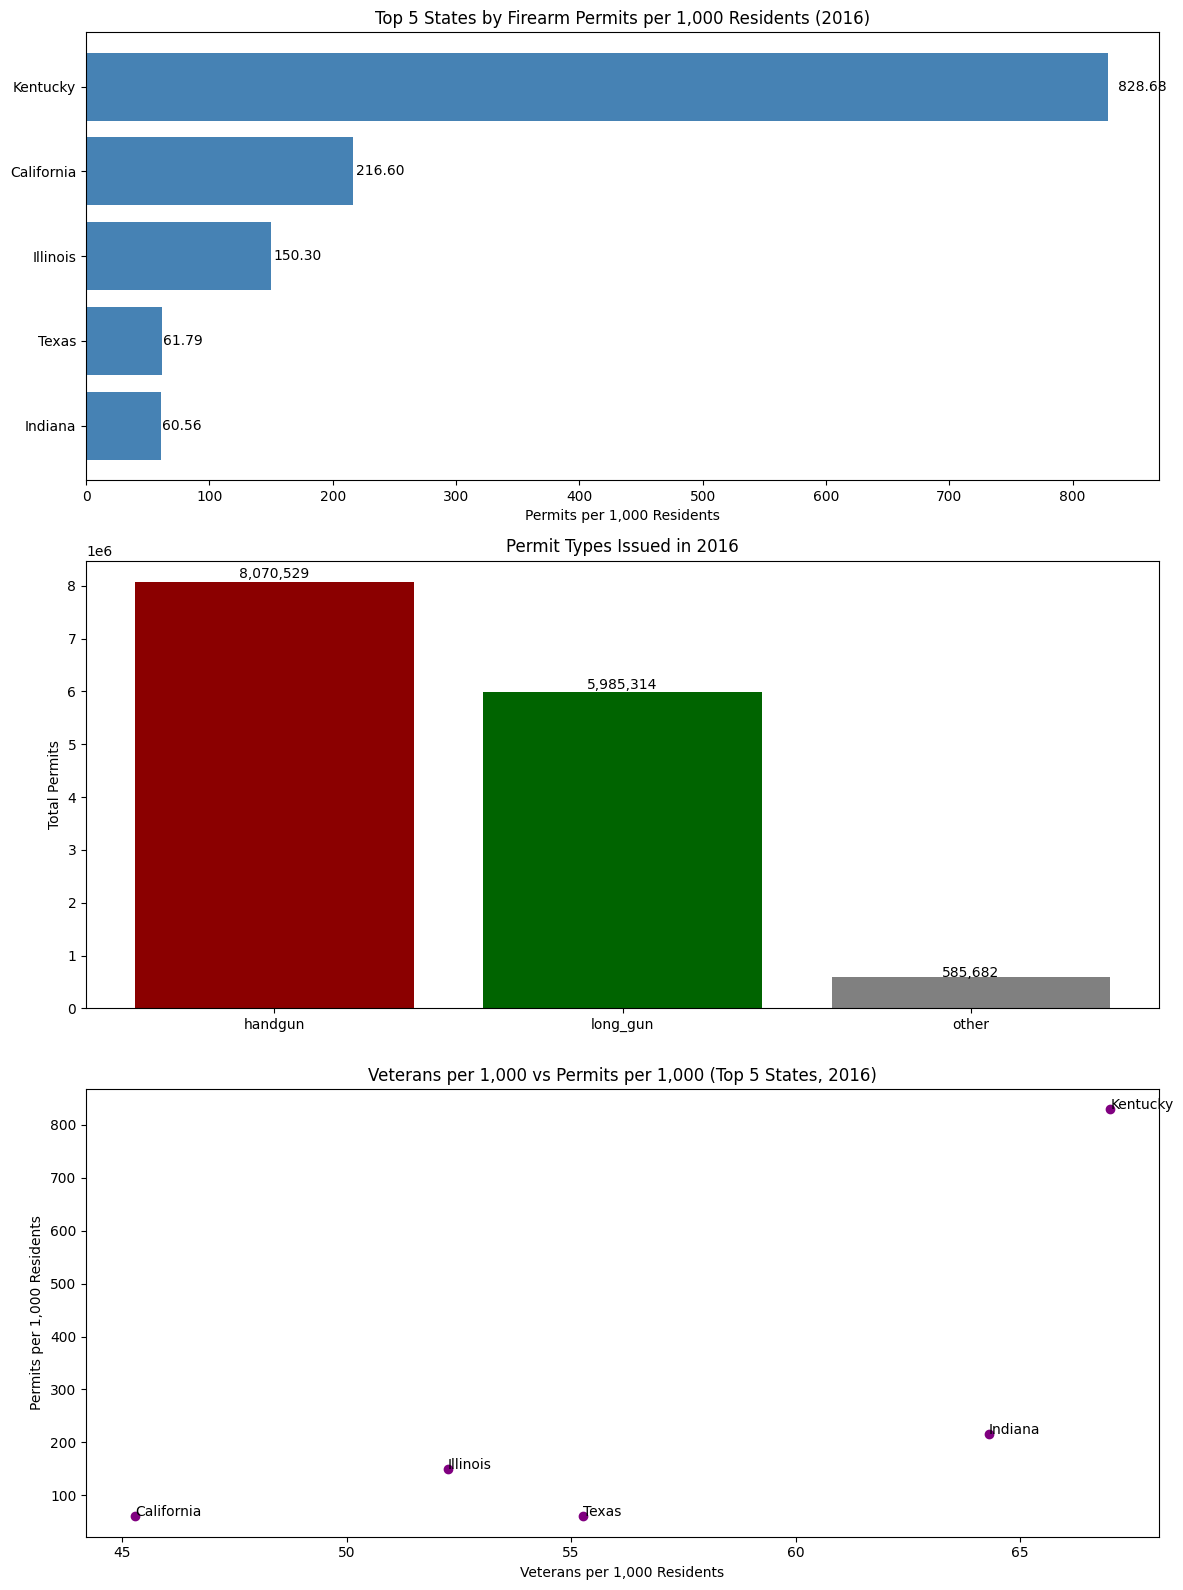

In [18]:
state_totals = (
    filtered_gun_data[filtered_gun_data['year'] == 2016]
    .groupby('state')['totals']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

# --- Inline: per-capita permits (permits per 1k residents) ---
pop_2016 = clean_census.set_index('state')['population_2016']
permits_per_1k = (state_totals / pop_2016.loc[state_totals.index]) * 1000

# --- Inline: permit type totals for 2016 ---
permit_types_2016 = (
    filtered_gun_data[filtered_gun_data['year'] == 2016][['handgun','long_gun','other']]
    .sum()
)

# --- Inline: veterans vs permits (per 1k veterans) ---
veterans = clean_census.set_index('state')['veterans']
veterans_per_1k = (veterans.loc[state_totals.index] / pop_2016.loc[state_totals.index]) * 1000

# --- Create vertical subplots ---
fig, axes = plt.subplots(3, 1, figsize=(12, 16))
ax1, ax2, ax3 = axes

# ============================================================
# 1️⃣ Subplot: Top 5 states (permits per 1k residents)
# ============================================================

sorted_totals = permits_per_1k.sort_values(ascending=False)

bars = ax1.barh(permits_per_1k.index, sorted_totals.values, color='steelblue')
ax1.set_title('Top 5 States by Firearm Permits per 1,000 Residents (2016)')
ax1.set_xlabel('Permits per 1,000 Residents')
ax1.invert_yaxis()

for bar in bars:
    width = bar.get_width()
    ax1.text(width * 1.01,
             bar.get_y() + bar.get_height()/2,
             f'{width:.2f}',
             va='center')

# ============================================================
# 2️⃣ Subplot: Permit type totals (handgun vs long gun vs other)
# ============================================================

ax2.bar(permit_types_2016.index, permit_types_2016.values,
        color=['darkred','darkgreen','gray'])
ax2.set_title('Permit Types Issued in 2016')
ax2.set_ylabel('Total Permits')

for i, v in enumerate(permit_types_2016.values):
    ax2.text(i, v * 1.01, f'{v:,}', ha='center')

# ============================================================
# 3️⃣ Subplot: Veterans per 1k vs permits per 1k (scatter)
# ============================================================

ax3.scatter(veterans_per_1k, permits_per_1k, color='purple')
ax3.set_title('Veterans per 1,000 vs Permits per 1,000 (Top 5 States, 2016)')
ax3.set_xlabel('Veterans per 1,000 Residents')
ax3.set_ylabel('Permits per 1,000 Residents')

for state in permits_per_1k.index:
    ax3.text(veterans_per_1k[state], permits_per_1k[state], state)

plt.tight_layout()
plt.show()

The charts show that Kentucky has by far the largest number of permit requests, and that most most permits are for handguns.
Of these five states, Kentucky had the highest number of veterans. This lead to a curiosity of which states had the most veterans and how those compared to Kentucky.

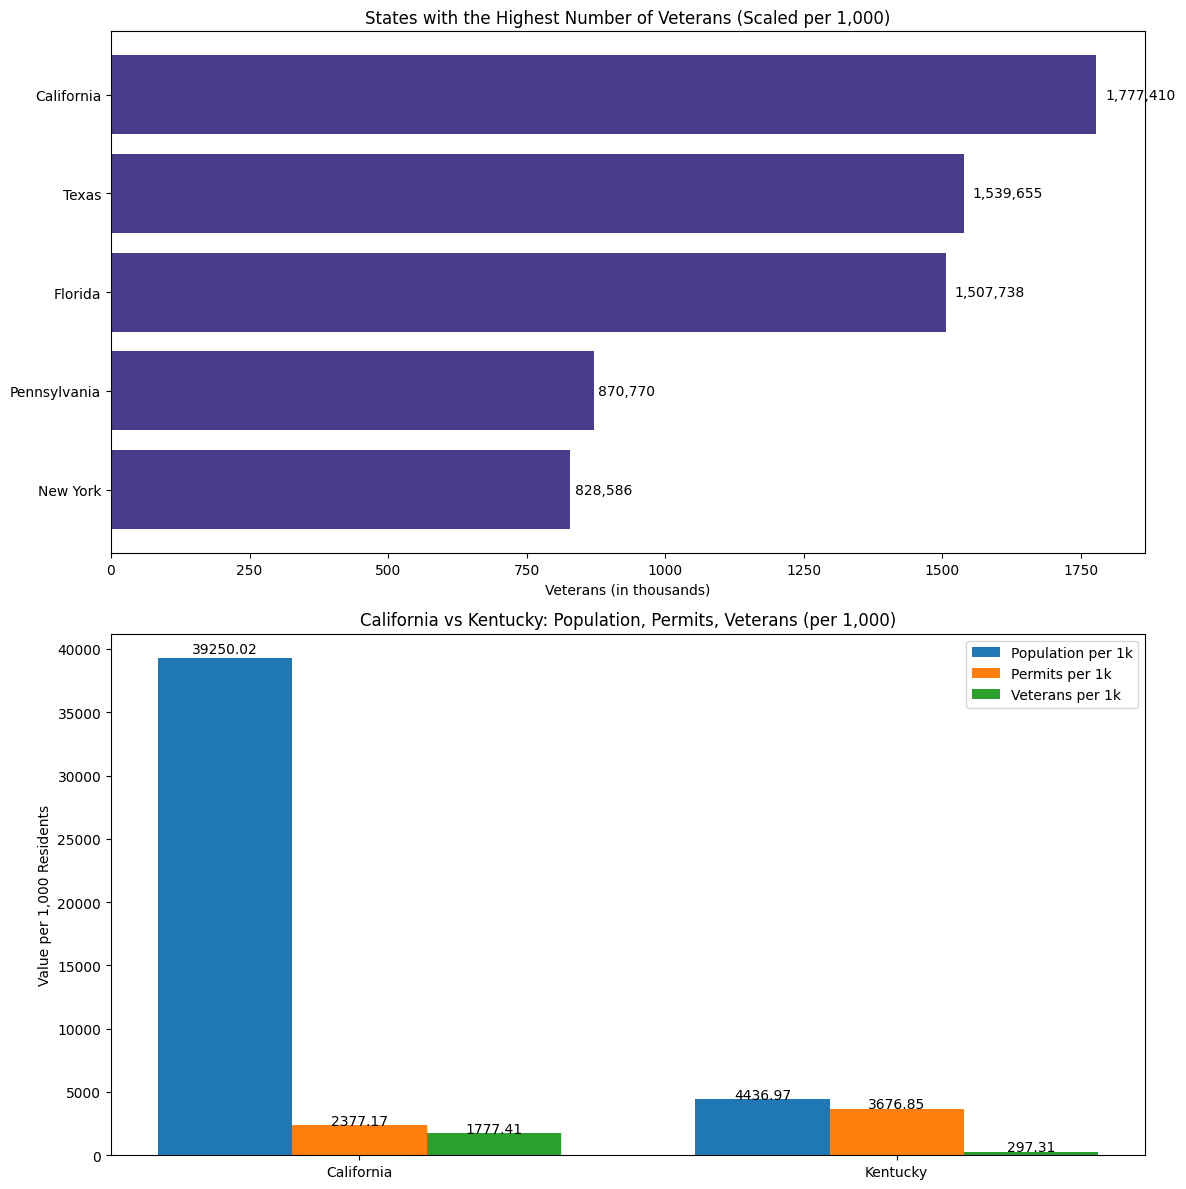

=== Kentucky Ranking by Veteran Size ===
Kentucky ranks 26 out of 50 states in number of veterans.

=== Population Size Comparison ===
California's population is 8.8 times more people than Kentucky.

=== Kentucky Permits as a Percentage of Population ===
Kentucky's population in 2016 was: 4436974
and the number of permits issued that year was: 3676.85(per 1,000 residents)
The number of permits issued represents approximately 82.87% of the state's population.
The difference between the number of permits issued in California: 2377.17(per 1,000 residents) and Kentucky: 3676.85(per 1,000 residents) is 1299.68(per 1,000 residents).


In [19]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# ============================================================
# 1️⃣ TOP SUBPLOT — Your existing veterans chart (scaled per 1,000)
# ============================================================

# Inline: sort → take top 5

# states sorted by highest number of veterans
veteran_ranking = top_veterans = (
    clean_census.set_index('state')['veterans']
    .sort_values(ascending=False)
)

top_veterans = veteran_ranking.head(5)

veterans_per_1k = top_veterans.values / 1000

bars1 = ax1.barh(top_veterans.index, veterans_per_1k, color='darkslateblue')
ax1.set_title('States with the Highest Number of Veterans (Scaled per 1,000)')
ax1.set_xlabel('Veterans (in thousands)')
ax1.invert_yaxis()

# Add numeric labels (original values)
for bar, original_value in zip(bars1, top_veterans.values):
    width = bar.get_width()
    ax1.text(
        width * 1.01,
        bar.get_y() + bar.get_height() / 2,
        f'{original_value:,}',
        va='center'
    )

# ============================================================
# 2️⃣ BOTTOM SUBPLOT — California vs Kentucky comparison (per 1,000)
# ============================================================

states = ['California', 'Kentucky']

# Extract census values
pop = clean_census.set_index('state').loc[states, 'population_2016']
vets = clean_census.set_index('state').loc[states, 'veterans']

# Extract permit totals for 2016
permits_2016 = (
    filtered_gun_data[filtered_gun_data['year'] == 2016]
    .groupby('state')['totals']
    .sum()
    .loc[states]
)

# Scale per 1,000 residents
pop_per_1k = pop / 1000
vets_per_1k = vets / 1000
permits_per_1k = permits_2016 / 1000

# Scale per 1,000 residents
max_val = max(pop_per_1k.max(), vets_per_1k.max(), permits_per_1k.max())
pop_scaled = pop_per_1k / max_val
vets_scaled = vets_per_1k / max_val
permits_scaled = permits_per_1k / max_val

metrics = {
    'Population per 1k': pop_per_1k,
    'Permits per 1k': permits_per_1k,
    'Veterans per 1k': vets_per_1k
}

# --- Vertical grouped bar chart ---
x = range(len(states))
bar_width = 0.25

for i, (label, values) in enumerate(metrics.items()):
    ax2.bar(
        [pos + i * bar_width for pos in x],
        values.values,
        width=bar_width,
        label=label
    )

ax2.set_xticks([pos + bar_width for pos in x])
ax2.set_xticklabels(states)
ax2.set_ylabel('Value per 1,000 Residents')
ax2.set_title('California vs Kentucky: Population, Permits, Veterans (per 1,000)')
ax2.legend()




# Add numeric labels
for i, (label, values) in enumerate(metrics.items()):
    for pos, val in zip(x, values.values):
        ax2.text(
            pos + i * bar_width,
            val * 1.01,
            f'{val:.2f}',
            ha='center'
        )

plt.tight_layout()
plt.show()

kentucky_rank = veteran_ranking.index.get_loc('Kentucky') + 1

population_ca = pop['California']
population_ky = pop['Kentucky']

permits_ca = permits_per_1k['California']
permits_ky = permits_per_1k['Kentucky']
permits_diff = permits_ky - permits_ca

ky_permit_pct = (permits_1k := permits_per_1k['Kentucky']) / (population_ky / 1000 ) * 100


print("=== Kentucky Ranking by Veteran Size ===")
print(f"Kentucky ranks {kentucky_rank} out of 50 states in number of veterans.")

print("\n=== Population Size Comparison ===")
print(f"California's population is {population_ca / population_ky:.1f} times more people than Kentucky.")
      
print("\n=== Kentucky Permits as a Percentage of Population ===")
print(f"Kentucky's population in 2016 was: {population_ky}")
print(f"and the number of permits issued that year was: {permits_ky:.2f}(per 1,000 residents)")
print(f"The number of permits issued represents approximately {ky_permit_pct:.2f}% of the state's population.")
print(f"The difference between the number of permits issued in California: {permits_ca:.2f}(per 1,000 residents) and Kentucky: {permits_ky:.2f}(per 1,000 residents) is {permits_diff:.2f}(per 1,000 residents).")


Surprisingly, when checking the list of states with the highest number of veterans, the size of Kentucky's veteran population is closer to the median, ranking 26 out of 50 states.  It can be concluded the the veteran population likely doesn't play a large part in the number of permits issued.

Comparing kentucky with the state with the largest veteran population, California, despite the population of kentucky being 8.8 times smaller than California, there were 1299.68 more permits issued per 1,000 residents in Kentucky. That amounts to 82.87% of the total population of Kentucky being issued permits.

From this data alone, it cannot be inferred why Kentucky had the highest number of permits issued for the year of 2016.

### Research Question 2: How have firearm background checks changed over time across U.S. states, and how do these trends relate to population size, veteran density, and permit activity? Which states show sustained increases, decreases, or stable patterns when these factors are considered together?

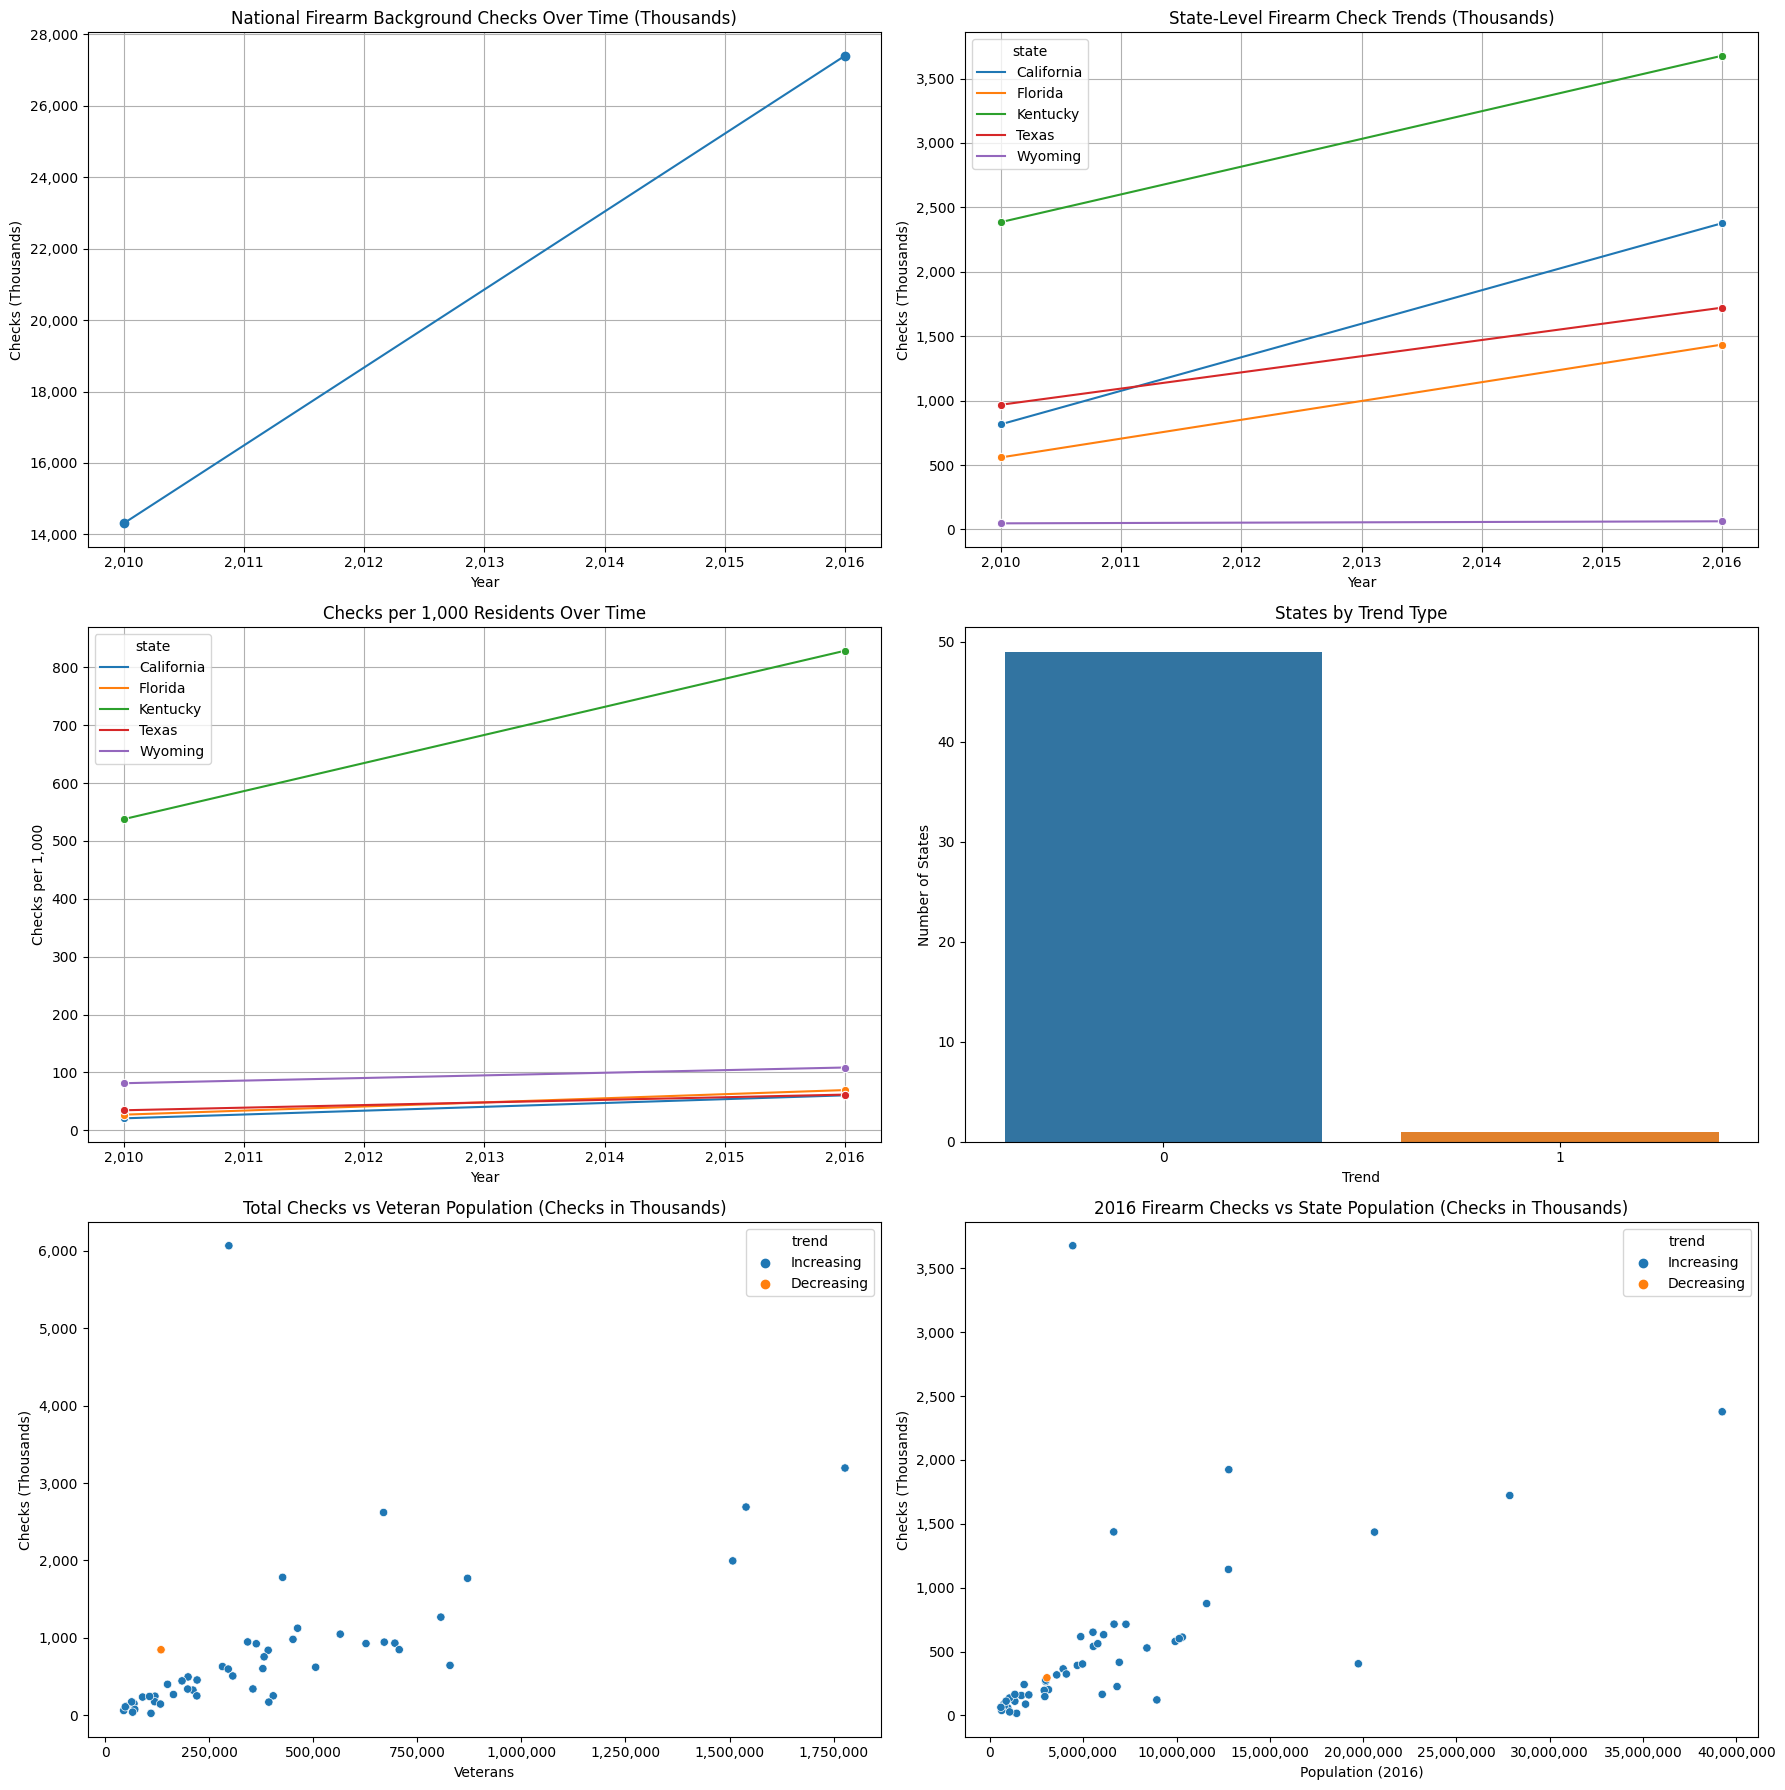

In [20]:
# investigating the overall trend in permits

fig, axes = plt.subplots(3, 2, figsize=(18, 18))
(ax1, ax2), (ax3, ax4), (ax5, ax6) = axes

# Helper: remove scientific notation
def clean_axis(ax):
        ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{x:,.0f}')
    )
        ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{x:,.0f}')
    )

# ============================================================
# 1️⃣ National firearm check trend (scaled)
# ============================================================

checks_by_year = (
    filtered_gun_data
    .groupby('year')['totals']
    .sum() / 1000   # SCALE
)

ax1.plot(checks_by_year.index, checks_by_year.values, marker='o')
ax1.set_title('National Firearm Background Checks Over Time (Thousands)')
ax1.set_xlabel('Year')
ax1.set_ylabel('Checks (Thousands)')
ax1.grid(True)
clean_axis(ax1)

# ============================================================
# 2️⃣ State-level trends (scaled)
# ============================================================

sample_states = ['California', 'Texas', 'Florida', 'Kentucky', 'Wyoming']

state_year_checks = (
    filtered_gun_data[filtered_gun_data['state'].isin(sample_states)]
    .groupby(['state', 'year'])['totals']
    .sum()
    .reset_index()
)

state_year_checks['totals_scaled'] = state_year_checks['totals'] / 1000

sns.lineplot(
    data=state_year_checks,
    x='year',
    y='totals_scaled',
    hue='state',
    marker='o',
    ax=ax2
)
ax2.set_title('State-Level Firearm Check Trends (Thousands)')
ax2.set_xlabel('Year')
ax2.set_ylabel('Checks (Thousands)')
ax2.grid(True)
clean_axis(ax2)

# ============================================================
# 3️⃣ Per-capita trends (already small values)
# ============================================================

pop_2016 = clean_census.set_index('state')['population_2016']

checks_state_year = (
    filtered_gun_data
    .groupby(['state', 'year'])['totals']
    .sum()
    .reset_index()
)

checks_state_year['population_2016'] = checks_state_year['state'].map(pop_2016)
checks_state_year['checks_per_1k'] = (
    checks_state_year['totals'] / checks_state_year['population_2016'] * 1000
)

sns.lineplot(
    data=checks_state_year[checks_state_year['state'].isin(sample_states)],
    x='year',
    y='checks_per_1k',
    hue='state',
    marker='o',
    ax=ax3
)
ax3.set_title('Checks per 1,000 Residents Over Time')
ax3.set_xlabel('Year')
ax3.set_ylabel('Checks per 1,000')
ax3.grid(True)
clean_axis(ax3)

# ============================================================
# 4️⃣ Trend classification (counts, no scaling needed)
# ============================================================

def compute_slope(group):
    years = group['year'].values
    totals = group['totals'].values
    if len(np.unique(years)) < 2:
        return np.nan
    return np.polyfit(years, totals, 1)[0]

state_trends = (
    filtered_gun_data
    .groupby('state')
    .apply(compute_slope)
    .reset_index(name='slope')
)

def classify_trend(slope):
    if slope > 0:
        return 'Increasing'
    elif slope < 0:
        return 'Decreasing'
    else:
        return 'Stable'

state_trends['trend'] = state_trends['slope'].apply(classify_trend)

sns.countplot(data=state_trends, x='trend', ax=ax4)
ax4.set_title('States by Trend Type')
ax4.set_xlabel('Trend')
ax4.set_ylabel('Number of States')
clean_axis(ax4)

# ============================================================
# 5️⃣ Checks vs veterans (scaled)
# ============================================================

vets = clean_census.set_index('state')['veterans']

checks_by_state = (
    filtered_gun_data
    .groupby('state')['totals']
    .sum() / 1000   # SCALE
)

trend_df = state_trends.set_index('state')
trend_df['total_checks_scaled'] = checks_by_state
trend_df['veterans'] = vets

sns.scatterplot(
    data=trend_df,
    x='veterans',
    y='total_checks_scaled',
    hue='trend',
    ax=ax5
)
ax5.set_title('Total Checks vs Veteran Population (Checks in Thousands)')
ax5.set_xlabel('Veterans')
ax5.set_ylabel('Checks (Thousands)')
clean_axis(ax5)

# ============================================================
#  Checks vs state population (scaled)
# ============================================================

# Population lookup
pop_2016 = clean_census.set_index('state')['population_2016']

# Total checks per state (scaled)
checks_2016_state = (
    filtered_gun_data[filtered_gun_data['year'] == 2016]
    .groupby('state')['totals']
    .sum() / 1000   # SCALE to thousands
)

# Add population + trend classification
pop_checks_df = (
    pd.DataFrame({
        'population_2016': pop_2016,
        'checks_2016_scaled': checks_2016_state
    })
    .dropna()
)

# Add trend classification (increasing / decreasing / stable)
pop_checks_df['trend'] = state_trends.set_index('state')['trend']

sns.scatterplot(
    data=pop_checks_df,
    x='population_2016',
    y='checks_2016_scaled',
    hue='trend',
    ax=ax6
)

ax6.set_title('2016 Firearm Checks vs State Population (Checks in Thousands)')
ax6.set_xlabel('Population (2016)')
ax6.set_ylabel('Checks (Thousands)')

clean_axis(ax6)

plt.tight_layout()
plt.show()


From the charts, the data overwhelimingly shows that the number of permit checks is overwhelmingly increasing.  
The scatter plots show that there is only 1 state that is decreasing in the number of checks.

In [21]:
# Investigating the state(s) that have declining numbers of permits
# Compute yearly permit totals per state
permits_state_year = (
    filtered_gun_data
    .groupby(['state', 'year'])['other']   # "other" = permit checks in NICS
    .sum()
    .reset_index()
)

# Compute slope (trend) for each state
def compute_slope(group):
    years = group['year'].values
    totals = group['other'].values
    if len(np.unique(years)) < 2:
        return np.nan
    return np.polyfit(years, totals, 1)[0]

permit_trends = (
    permits_state_year
    .groupby('state')
    .apply(compute_slope)
    .reset_index(name='slope')
)

# Filter decreasing states
decreasing_permit_states = permit_trends[permit_trends['slope'] < 0]

# Top 5 fastest-declining states
top5_declining = (
    decreasing_permit_states
    .sort_values('slope')
    .head(5)['state']
    .tolist()
)

print("\n=== Investigating the states where number of checks are declining ===")
print(f"Total number of states where checks are declining: {len(top5_declining)}")
print(f"Top 5 states where checks are declining: {', '.join(top5_declining)}")


=== Investigating the states where number of checks are declining ===
Total number of states where checks are declining: 1
Top 5 states where checks are declining: Illinois


In [22]:
# Investigate the states where things have remained constant(+/-5%)

# Yearly totals per state
state_year = (
    filtered_gun_data
    .groupby(['state', 'year'])['totals']
    .sum()
    .reset_index()
)

# Compute percent change
state_year['pct_change'] = (
    state_year.groupby('state')['totals']
    .pct_change() * 100
)

bands = range(5, 45, 5)   # 5, 10, 15, 20, 25, 30, 35, 40

stable_by_band = {}

for band in bands:
    stable_states = (
        state_year
        .groupby('state')['pct_change']
        .apply(lambda s: s.dropna().abs().le(band).all())
    )
    
    stable_states = stable_states[stable_states].index.tolist()
    stable_by_band[band] = stable_states

# Print results
for band, states in stable_by_band.items():
    print(f"States within ±{band}% year‑to‑year change:")
    print(states)
    print()

print("\n=== Investigating the number of states where the number of checks has changed by +/- 5% ===")
print(f"Total number of states where the checks has remained consistent: {len(stable_states)}")

States within ±5% year‑to‑year change:
[]

States within ±10% year‑to‑year change:
[]

States within ±15% year‑to‑year change:
[]

States within ±20% year‑to‑year change:
[]

States within ±25% year‑to‑year change:
[]

States within ±30% year‑to‑year change:
[]

States within ±35% year‑to‑year change:
['Alaska', 'Montana', 'Wyoming']

States within ±40% year‑to‑year change:
['Alaska', 'Arkansas', 'Kansas', 'Montana', 'Wyoming']


=== Investigating the number of states where the number of checks has changed by +/- 5% ===
Total number of states where the checks has remained consistent: 5


From the data, it can be concluded that overwelmingly, the number of background checks is increasing across the country, with handguns being the primary permit. Illinois is an outlier that requires additional data beyond the scope of the census data to explain why there was a decrease in background checks. Any attempt to explain the decrease from this data alone would be purely conjecture. There are myriad factors that could affect this.

Likewise, there are no states that have remained constant. Attempting to discern which states were closest to their previous recorded values with a ever widing percentage gap, the states that were closest to their previous year's data had an increase of 35%.

### Research Question 3: How do firearm background check trends relate to demographic and socioeconomic characteristics across states (e.g., income, education, poverty, urbanization)?

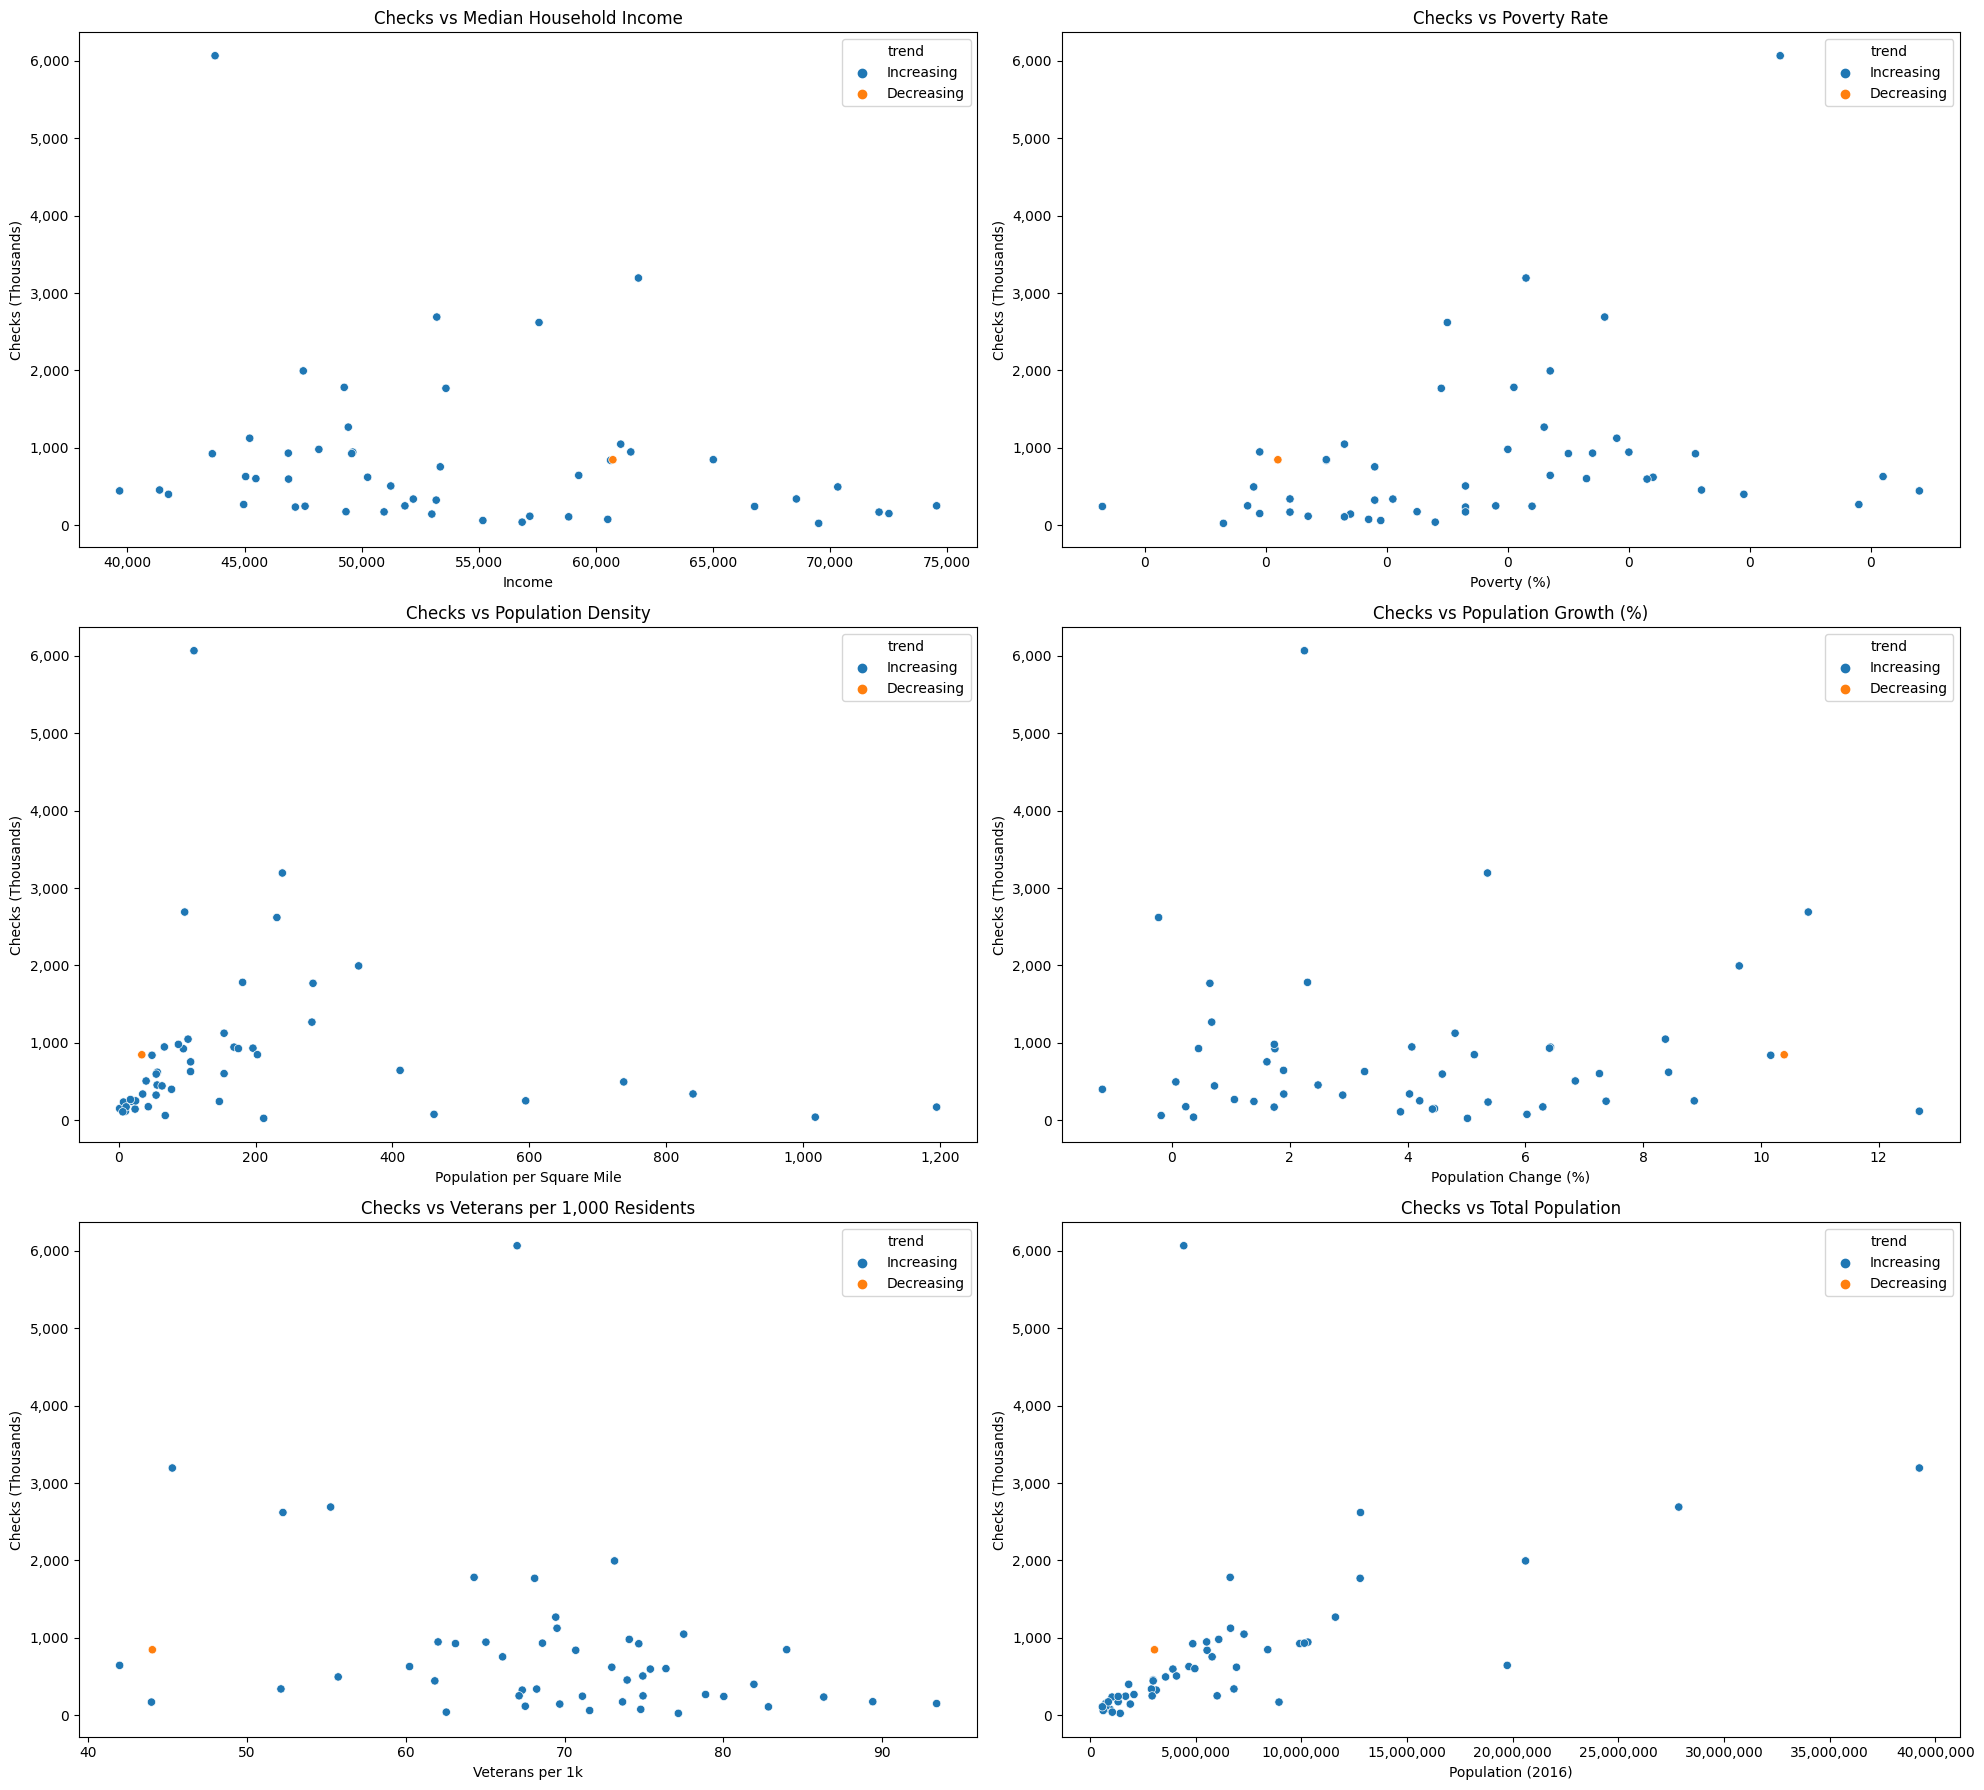

In [23]:

# ------------------------------------------------------------
# Build combined dataframe
# ------------------------------------------------------------

checks_scaled = (
    filtered_gun_data
    .groupby('state')['totals']
    .sum() / 1000
)

pct_increase = (
    filtered_gun_data.groupby('state')['totals'].apply(
        lambda s: (s.iloc[-1] - s.iloc[0]) / s.iloc[0] * 100
    )
)

trend_map = state_trends.set_index('state')['trend']

demo_df = clean_census.set_index('state').copy()
demo_df['checks_scaled'] = checks_scaled
demo_df['pct_increase'] = pct_increase
demo_df['trend'] = trend_map

# ------------------------------------------------------------
# Plot grid (3 rows × 2 columns)
# ------------------------------------------------------------

fig, axes = plt.subplots(3, 2, figsize=(20, 18))
(ax1, ax2), (ax3, ax4), (ax5, ax6) = axes

# 1️⃣ Income vs checks
sns.scatterplot(
    data=demo_df,
    x='median_household_income',
    y='checks_scaled',
    hue='trend',
    ax=ax1
)
ax1.set_title('Checks vs Median Household Income')
ax1.set_xlabel('Income')
ax1.set_ylabel('Checks (Thousands)')
clean_axis(ax1)

# 2️⃣ Poverty vs checks
sns.scatterplot(
    data=demo_df,
    x='persons_in_poverty_pct',
    y='checks_scaled',
    hue='trend',
    ax=ax2
)
ax2.set_title('Checks vs Poverty Rate')
ax2.set_xlabel('Poverty (%)')
ax2.set_ylabel('Checks (Thousands)')
clean_axis(ax2)

# 3️⃣ Population density vs checks
sns.scatterplot(
    data=demo_df,
    x='population_density',
    y='checks_scaled',
    hue='trend',
    ax=ax3
)
ax3.set_title('Checks vs Population Density')
ax3.set_xlabel('Population per Square Mile')
ax3.set_ylabel('Checks (Thousands)')
clean_axis(ax3)

# 4️⃣ Population change vs checks
sns.scatterplot(
    data=demo_df,
    x='population_change_pct',
    y='checks_scaled',
    hue='trend',
    ax=ax4
)
ax4.set_title('Checks vs Population Growth (%)')
ax4.set_xlabel('Population Change (%)')
ax4.set_ylabel('Checks (Thousands)')
clean_axis(ax4)

# 5️⃣ Veterans per 1k vs checks
sns.scatterplot(
    data=demo_df,
    x='veterans_per_1k',
    y='checks_scaled',
    hue='trend',
    ax=ax5
)
ax5.set_title('Checks vs Veterans per 1,000 Residents')
ax5.set_xlabel('Veterans per 1k')
ax5.set_ylabel('Checks (Thousands)')
clean_axis(ax5)

# 6️⃣ Population vs checks
sns.scatterplot(
    data=demo_df,
    x='population_2016',
    y='checks_scaled',
    hue='trend',
    ax=ax6
)
ax6.set_title('Checks vs Total Population')
ax6.set_xlabel('Population (2016)')
ax6.set_ylabel('Checks (Thousands)')
clean_axis(ax6)

plt.tight_layout()
plt.show()

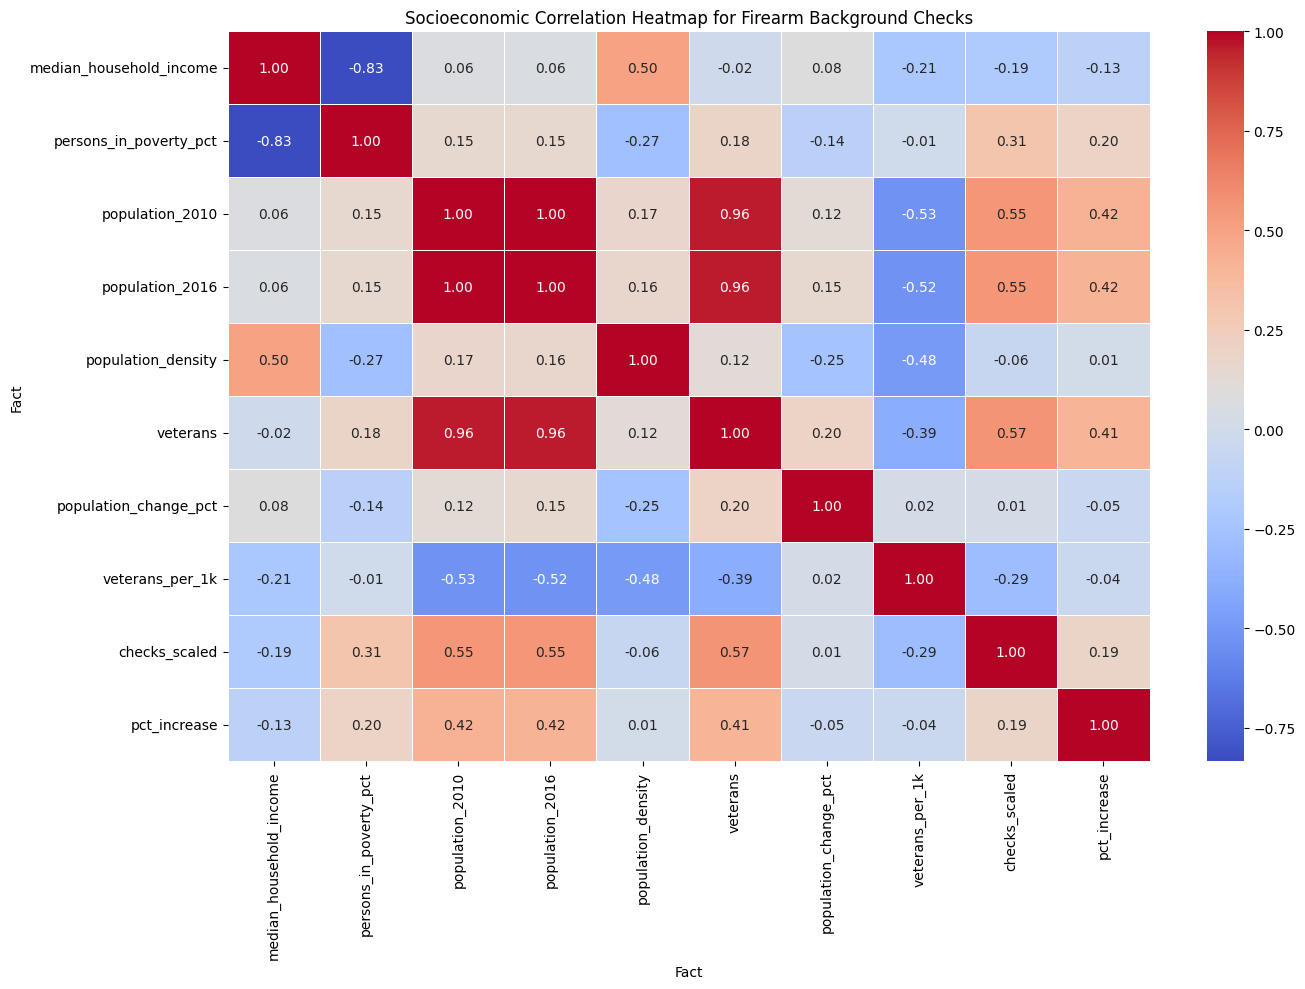

In [24]:
# Build combined dataframe using only columns that exist
heatmap_df = clean_census.set_index('state').copy()

# Add firearm check metrics
heatmap_df['checks_scaled'] = (
    filtered_gun_data
    .groupby('state')['totals']
    .sum() / 1000
)

heatmap_df['pct_increase'] = (
    filtered_gun_data.groupby('state')['totals'].apply(
        lambda s: (s.iloc[-1] - s.iloc[0]) / s.iloc[0] * 100
    )
)

# Select only numeric columns for correlation
numeric_cols = [
    'median_household_income',
    'persons_in_poverty_pct',
    'population_2010',
    'population_2016',
    'population_density',
    'veterans',
    'population_change_pct',
    'veterans_per_1k',
    'checks_scaled',
    'pct_increase'
]

corr = heatmap_df[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    fmt=".2f"
)
plt.title('Socioeconomic Correlation Heatmap for Firearm Background Checks')
plt.tight_layout()
plt.show()

Checking financial data compared to the number of background checks shows that there is no real correlation between income or poverty and background checks. Looking at the charts above, the plots for median income and poverty show that income is not a meaningful predictor of background check growth. High poverty states do not cluster at higher or low check levels and high income states do not cluster at high check levels. Verteran population doesn't have a substantial impact.  

The only real trend shown is in total population and population density. Places with more people(total population) have a larger number of total checks simply because they have a larger population, while small states have high *per capita* checks but lower *total checks* than larger states. Likewise states with low density, ie rural states, have higher checks per capita despite total volume as compared to high density states which have lower volume. This falls in line with known cultural patterns. Rural states with less urban area have more hunting, sport shooting and firearm culture, whereas urban states(highly dense places) have more restrictive laws and lower per-capita checks.

<a id='conclusions'></a>
## Conclusions

Overall, handguns are the most popular background check. In the years between 2010 and 2016, aligning with the census data, the number of background checks has increased across the country except for one state. Overall, there is no apparent correlation between income and the number of background checks. The only consistent correlation is between the total population and the population density. Simply put, states with more population will have more background checks, and states with more open country and less urban centers will have more background checks *per capita*.

One area where additional research could shed more light to explain background check trends would be to investigating crime statistics. How do states with high background checks correlate to crime statistics? Do states with high background checks also have high crime statistics? 

The scope of this data exploration was limited to total number of checks and not exploring the depths of types of permits, such as rentals or pawns. This was decided to get the broadest slice of overal trends in the data by focusing on the total, but could also be interesting to explore. Are the other types of permits and rechecks that substantial compare to the number of new permits and is there any interesting correlations in the data?

Another limitation is in the census data. This has a gap of 6 years between 2010 and 2016. Utilizing an annual source of population and economic data would show the trend more clearly rather than a 6 year gap as seen in the census data.

## Submitting your Project 


In [25]:
# Running this cell will execute a bash command to convert this notebook to an .html file
!python -m nbconvert --to html Investigate_a_Dataset.ipynb

[NbConvertApp] Converting notebook Investigate_a_Dataset.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 5 image(s).
[NbConvertApp] Writing 1349532 bytes to Investigate_a_Dataset.html
